# 04 — Diamond Price Prediction (ANN Regression)**Step 7 of the brief.** This one works *well* — which makes it the right place to learnwhat a good regression setup looks like, and the one transformation that makes thedifference between a mediocre model and a strong one.

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))   # [so `from src...` works from notebooks/]

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from src.config import *

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 40)

In [2]:
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Stabilize TensorFlow runtime on older macOS Intel machines.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["TF_NUM_INTRAOP_THREADS"] = "1"
os.environ["TF_NUM_INTEROP_THREADS"] = "1"

import tensorflow as tf
import keras
layers = keras.layers

from src.data_prep import build, split_scaled, REG_FEATURES

tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)

df = build(verbose=False)
print("price skew:", round(df["price"].skew(), 2))

price skew: 1.62


## The key decision: predict **log(price)**, not price`price` runs from about \$326 to \$18,823 and is heavily right-skewed.A neural net minimising **mean squared error** on raw price is minimising *squared dollars*.An error of \$2,000 on an \$18,000 stone contributes 4,000,000 to the loss. An error of \$200on a \$500 stone contributes 40,000 — **one hundred times less**. The network will thereforespend essentially all its capacity getting the handful of very expensive stones approximatelyright, and treat the thousands of cheap ones as rounding error.But **being \$200 out on a \$500 diamond is a catastrophic 40% error**, and being \$2,000 outon an \$18,000 one is a tolerable 11%. Raw-dollar MSE has its priorities exactly backwards.Training on `log(price)` fixes this. In log space, a *proportional* error costs the sameregardless of scale — so the model optimises for **percentage accuracy**, which is whatactually matters commercially. We then exponentiate back to dollars to report the metrics,because "your model is off by 0.11 log-dollars" is not a sentence anyone can act on.

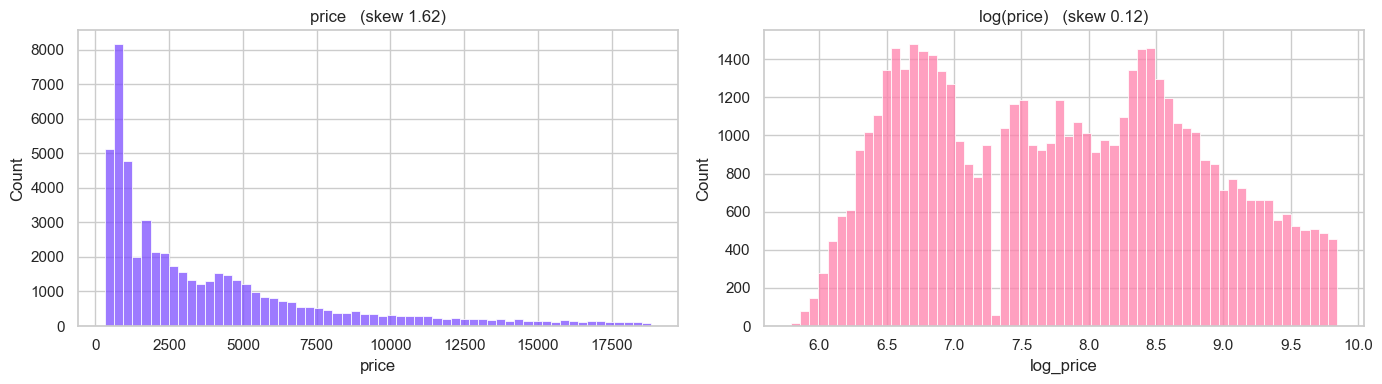

In [3]:
df["log_price"] = np.log1p(df["price"])   # [log1p = log(1+x); safe if a value were ever 0]

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["price"], bins=60, ax=ax[0], color=PALETTE["primary"])
ax[0].set_title(f"price   (skew {df['price'].skew():.2f})")

sns.histplot(df["log_price"], bins=60, ax=ax[1], color=PALETTE["secondary"])
ax[1].set_title(f"log(price)   (skew {df['log_price'].skew():.2f})")

plt.tight_layout()
plt.show()

Skew drops from roughly +1.6 to near 0. The long tail is gone and the target is now close to symmetric — much friendlier ground for a squared-error loss.

In [4]:
X_tr, X_val, X_te, y_tr, y_val, y_te, scaler = split_scaled(
    df, REG_FEATURES, "log_price"
)
print(f"train {X_tr.shape}  val {X_val.shape}  test {X_te.shape}")
print("features:", REG_FEATURES)
print("\n[note: price, log_price and price_per_carat are all ABSENT from the features.]")

train (37636, 13)  val (5376, 13)  test (10754, 13)
features: ['carat', 'log_carat', 'depth', 'table', 'x', 'y', 'z', 'volume', 'density', 'xy_ratio', 'cut_rank', 'color_rank', 'clarity_rank']

[note: price, log_price and price_per_carat are all ABSENT from the features.]


## Baseline first, again

In [5]:
base_pred = np.full_like(y_te, y_tr.mean())
base_dollars = np.expm1(base_pred)
true_dollars = np.expm1(y_te)

print(f"Always-guess-the-mean MAE: ${mean_absolute_error(true_dollars, base_dollars):,.0f}")
print(f"Always-guess-the-mean R2:  {r2_score(true_dollars, base_dollars):.4f}   <- R2 of 0 BY DEFINITION")

Always-guess-the-mean MAE: $2,787
Always-guess-the-mean R2:  -0.1485   <- R2 of 0 BY DEFINITION


**This is what R² actually means.** R² = 0 is not "no correlation" — it is *"exactly as good asalways guessing the average."* R² = 1 is perfect. R² *can be negative*, which means your modelis worse than a model that ignores the inputs entirely. Anchoring on that makes the numberinterpretable instead of magical.

## The network

In [6]:
def build_regressor(input_dim):
    m = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),

        layers.Dense(1, activation="linear"),   # [LINEAR, not softmax, not sigmoid]
    ])
    m.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="mse",
        metrics=["mae"],
    )
    return m

reg = build_regressor(X_tr.shape[1])
reg.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,385 (189.00 KB)

 Trainable params: 47,617 (186.00 KB)

 Non-trainable params: 768 (3.00 KB)

### The one line that separates regression from classification```layers.Dense(1, activation="linear")```**A regression output layer must be linear** — that is, no activation function at all. Thenetwork needs to output *any real number*, unbounded. A sigmoid would clamp it to 0–1; asoftmax on one unit would pin it to exactly 1.0 (the bug from the Credit-G task); a ReLU wouldforbid negative outputs.The output activation is not a style choice. It is dictated by the **range of the thing you arepredicting**:| Task | Output layer | Loss ||---|---|---|| Binary classification | `1 unit, sigmoid` | `binary_crossentropy` || Multi-class (8 grades) | `8 units, softmax` | `sparse_categorical_crossentropy` || Regression (a price) | `1 unit, linear` | `mse` |**Everything before the output layer is nearly identical across all three.** The architecture ofthe hidden layers barely changes. What makes a network a classifier or a regressor is the lastlayer and the loss function. That's the whole difference — and once you see it, a lot of deeplearning stops looking mysterious.**`loss="mse"`, `metrics=["mae"]`** — MSE is what gets *optimised* (squaring makes itdifferentiable and punishes large errors hard). MAE is what gets *reported*, because "averageerror of \$340" is a sentence a human understands and "average squared error of 115,600" is not.

## Train

In [7]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5, verbose=1
    ),
]

history = reg.fit(
    X_tr,
    y_tr,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=64,
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/80
589/589 - 3s - 5ms/step - loss: 1.1726 - mae: 0.6797 - val_loss: 0.2921 - val_mae: 0.4683 - learning_rate: 0.0010
Epoch 2/80
589/589 - 1s - 2ms/step - loss: 0.3123 - mae: 0.4406 - val_loss: 0.3167 - val_mae: 0.5124 - learning_rate: 0.0010
Epoch 3/80
589/589 - 1s - 2ms/step - loss: 0.2482 - mae: 0.3920 - val_loss: 0.3047 - val_mae: 0.4838 - learning_rate: 0.0010
Epoch 4/80
589/589 - 1s - 2ms/step - loss: 0.2003 - mae: 0.3528 - val_loss: 0.2862 - val_mae: 0.4852 - learning_rate: 0.0010
Epoch 5/80
589/589 - 1s - 2ms/step - loss: 0.1652 - mae: 0.3196 - val_loss: 0.2783 - val_mae: 0.4402 - learning_rate: 0.0010
Epoch 6/80
589/589 - 1s - 2ms/step - loss: 0.1314 - mae: 0.2848 - val_loss: 0.2361 - val_mae: 0.4267 - learning_rate: 0.0010
Epoch 7/80
589/589 - 1s - 2ms/step - loss: 0.1085 - mae: 0.2575 - val_loss: 0.1680 - val_mae: 0.3310 - learning_rate: 0.0010
Epoch 8/80
589/589 - 1s - 2ms/step - loss: 0.0900 - mae: 0.2342 - val_loss: 0.1044 - val_mae: 0.2844 - learning_rate: 0.0010


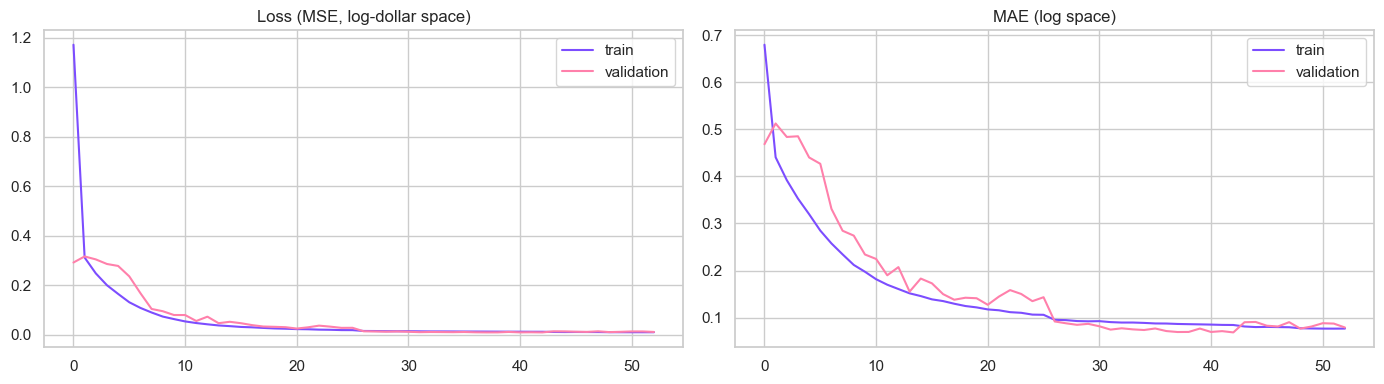

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(history.history["loss"], label="train", color=PALETTE["primary"])
ax[0].plot(history.history["val_loss"], label="validation", color=PALETTE["secondary"])
ax[0].set_title("Loss (MSE, log-dollar space)")
ax[0].legend()

ax[1].plot(history.history["mae"], label="train", color=PALETTE["primary"])
ax[1].plot(history.history["val_mae"], label="validation", color=PALETTE["secondary"])
ax[1].set_title("MAE (log space)")
ax[1].legend()

plt.tight_layout()
plt.show()

## Evaluate — back in dollars, where the numbers mean something

In [9]:
pred_log = reg.predict(X_te, verbose=0).flatten()
# [expm1 is the exact inverse of log1p - undo the transform to get real dollars back]
y_pred_d = np.expm1(pred_log)
y_true_d = np.expm1(y_te)

mae = mean_absolute_error(y_true_d, y_pred_d)
mse = mean_squared_error(y_true_d, y_pred_d)
rmse = np.sqrt(mse)
r2 = r2_score(y_true_d, y_pred_d)
mape = np.mean(np.abs((y_true_d - y_pred_d) / y_true_d)) * 100

print(f"MAE    ${mae:>12,.2f}    average miss, in plain dollars")
print(f"MSE     {mse:>13,.2f}    squared dollars - not interpretable, but it is what we optimised")
print(f"RMSE   ${rmse:>12,.2f}    same units as price; > MAE means a few big misses exist")
print(f"R2      {r2:>13.4f}    fraction of price variance explained")
print(f"MAPE    {mape:>12.2f}%   average error as a percentage")

MAE    $      309.47    average miss, in plain dollars
MSE        389,081.90    squared dollars - not interpretable, but it is what we optimised
RMSE   $      623.76    same units as price; > MAE means a few big misses exist
R2             0.9750    fraction of price variance explained
MAPE            6.84%   average error as a percentage


### The four metrics, and what each one is *for*- **MAE** — the average miss, in dollars. The most human-readable number here. Treats a \$100  error as exactly twice as bad as a \$50 one.- **MSE** — squared dollars. Not interpretable as a quantity, but it's what the optimiser  minimises, because squaring is smooth (differentiable everywhere) and punishes big misses hard.- **RMSE** — the square root of MSE, so it's back in dollars and comparable to MAE. **Here is  the trick: RMSE ≥ MAE always, and the size of the gap tells you about your error  distribution.** RMSE close to MAE means errors are uniform. RMSE much larger than MAE means a  few big misses are dominating — and those are worth going and looking at.- **R²** — the fraction of price variance the model explains. 0 = no better than guessing the  mean. 1 = perfect. Scale-free, so you can compare it across datasets in a way you cannot  compare MAE.- **MAPE** — error as a percentage. Since we trained in log space, this is arguably the metric  the model was *actually* optimising, and it's the one a jeweller would care about.Expect **R² around 0.98** and **MAE somewhere near \$300–400**. Price is genuinely learnable fromthese features — carat alone correlates above 0.9 with it. This is what a *working* model lookslike, and the contrast with the clarity classifier is the whole lesson: **the same architecture,the same effort, wildly different outcomes — because the signal was there in one case and mostlyabsent in the other.** Model quality is bounded by what the features actually contain. No amountof tuning conjures information that isn't in the data.

## Diagnostics — where does it fail?

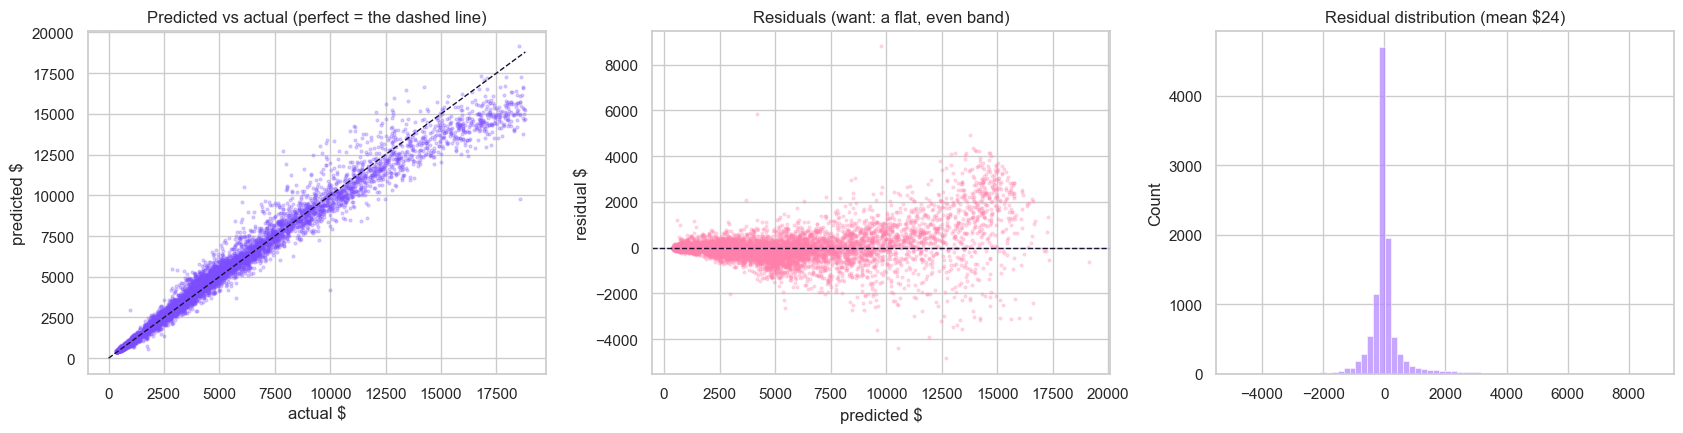

In [10]:
resid = y_true_d - y_pred_d

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
ax[0].scatter(y_true_d, y_pred_d, s=4, alpha=0.25, color=PALETTE["primary"])
lims = [0, y_true_d.max()]
ax[0].plot(lims, lims, "--", color=PALETTE["ink"], lw=1)
ax[0].set_xlabel("actual $")
ax[0].set_ylabel("predicted $")
ax[0].set_title("Predicted vs actual (perfect = the dashed line)")

ax[1].scatter(y_pred_d, resid, s=4, alpha=0.25, color=PALETTE["secondary"])
ax[1].axhline(0, color=PALETTE["ink"], ls="--", lw=1)
ax[1].set_xlabel("predicted $")
ax[1].set_ylabel("residual $")
ax[1].set_title("Residuals (want: a flat, even band)")

sns.histplot(resid, bins=70, ax=ax[2], color=PALETTE["accent"])
ax[2].set_title(f"Residual distribution (mean ${resid.mean():,.0f})")

plt.tight_layout()
plt.show()

In [11]:
band = pd.cut(y_true_d, [0, 1000, 2500, 5000, 10000, 20000])
err = pd.DataFrame(
    {
        "actual": y_true_d,
        "abs_err": np.abs(resid),
        "pct_err": np.abs(resid) / y_true_d * 100,
        "band": band,
    }
)

print("Error by price band:\n")
print(
    err.groupby("band", observed=True)[["abs_err", "pct_err"]]
    .agg(["mean", "count"])
    .round(1)
    .to_string()
)

Error by price band:

               abs_err       pct_err      
                  mean count    mean count
band                                      
(0, 1000]         36.4  2878     5.2  2878
(1000, 2500]     111.7  2570     6.6  2570
(2500, 5000]     309.5  2361     8.3  2361
(5000, 10000]    456.8  1934     6.6  1934
(10000, 20000]  1307.6  1011     9.1  1011


**This table is the most valuable output in the notebook, and it is the kind of thing a singleR² score hides completely.**Absolute error *rises* with price (a \$500 miss on a \$15,000 stone is unremarkable) while**percentage error stays roughly flat across the bands** — which is precisely what the logtransform was supposed to buy us. The model is proportionally consistent. That is the evidencethat the design decision worked, and it's a far more convincing thing to put in a report than"R² = 0.98".

In [12]:
reg.save(MODEL_DIR / "price_regressor.keras")

import joblib
joblib.dump(scaler, MODEL_DIR / "price_scaler.pkl")

results_reg = {
    "mae": float(mae),
    "mse": float(mse),
    "rmse": float(rmse),
    "r2": float(r2),
    "mape": float(mape),
}
pd.Series(results_reg).to_json(RESULT_DIR / "regression_results.json")
print("saved model + scaler + results")

saved model + scaler + results
